In [8]:
import pandas as pd
from google.colab import files

# 1. Read the file directly using its exact name
file_name = 'Unemployment-data.csv' # Removed leading space
df = pd.read_csv(file_name)

# 2. Automatic translation of columns and values
df.rename(columns={'الربع': 'Quarter', 'الجنس': 'Gender', 'معدل البطالة': 'Unemployment_Rate'}, inplace=True)

if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'ذكور': 'Male', 'إناث': 'Female', 'الإجمالي': 'Total'}).fillna(df['Gender'])

# 3. Save the new file and download it to your device
df.to_csv('Saudi_Unemployment_English.csv', index=False)
files.download('Saudi_Unemployment_English.csv')

print("Download completed successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download completed successfully!


In [9]:
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Check and remove missing values
print(df.isnull().sum())

df = df.dropna()

# 3. Keep only Male and Female rows
df = df[df['Gender'].isin(['Male', 'Female'])]

# 4. Convert unemployment rate to numeric
df['Unemployment_Rate'] = pd.to_numeric(
    df['Unemployment_Rate'],
    errors='coerce'
)

# 5. Extract year and quarter number
df['Year'] = df['Quarter'].str.split('-').str[0].astype(int)

df['Quarter_Number'] = (
    df['Quarter']
    .str.split('-').str[1]
    .str.replace('Q', '')
    .astype(int)
)

# 6. Remove Quarter column
df = df.drop(columns=['Quarter'])

# 7. Arrange columns
df = df[['Year', 'Quarter_Number', 'Gender', 'Unemployment_Rate']]

# 8. Sort data
df = df.sort_values(
    by=['Year', 'Quarter_Number', 'Gender']
).reset_index(drop=True)

# 9. Show cleaned data
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nGender values:")
print(df['Gender'].unique())

print("\nMissing Values:")
print(df.isnull().sum())

# 10. Save cleaned dataset
df.to_csv('cleaned_unemployment_data.csv', index=False)
files.download('cleaned_unemployment_data.csv')

print("\nCleaned dataset saved successfully.")

Quarter              0
Gender               0
Unemployment_Rate    0
dtype: int64
   Year  Quarter_Number  Gender  Unemployment_Rate
0  2016               2  Female               33.7
1  2016               2    Male                5.4
2  2016               3  Female               34.5
3  2016               3    Male                5.7
4  2016               4  Female               34.5

Columns:
Index(['Year', 'Quarter_Number', 'Gender', 'Unemployment_Rate'], dtype='object')

Gender values:
['Female' 'Male']

Missing Values:
Year                 0
Quarter_Number       0
Gender               0
Unemployment_Rate    0
dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Cleaned dataset saved successfully.


In [10]:
# TRAINING MODULE

# Data Preparation

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load and prepare data
df = pd.read_csv("cleaned_unemployment_data.csv")

df = df.sort_values(
    ["Gender", "Year", "Quarter_Number"]
).reset_index(drop=True)

# Time index per gender
df["t"] = df.groupby("Gender").cumcount()

test_size = 10

linear_models = {}
poly_models = {}
holt_models = {}

test_data = {}

print("Data prepared successfully.")

Data prepared successfully.


In [11]:
# Model Training

for gender in sorted(df["Gender"].unique()):

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    X_gender = gdf[["t"]].values
    y_gender = gdf["Unemployment_Rate"].values

    # Safety check
    if len(y_gender) <= test_size:
        print(f"Skipping {gender}: not enough data.")
        continue

    split_idx = len(y_gender) - test_size

    X_train = X_gender[:split_idx]
    X_test = X_gender[split_idx:]

    y_train = y_gender[:split_idx]
    y_test = y_gender[split_idx:]

    # Save test sets and quarters
    test_data[gender] = {
        "X_test": X_test,
        "y_test": y_test,
        "quarters": gdf["Quarter_Number"].iloc[split_idx:]
    }

    # 1) Linear Regression
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)

    linear_models[gender] = linear_model

    # 2) Polynomial Regression
    poly_model = make_pipeline(
        PolynomialFeatures(
            degree=2,
            include_bias=False
        ),
        LinearRegression()
    )

    poly_model.fit(X_train, y_train)

    poly_models[gender] = poly_model

    # 3) Holt-Winters
    hw = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=4
    ).fit(optimized=True)

    holt_models[gender] = hw

print("Linear Regression trained successfully for both genders.")
print("Polynomial Regression trained successfully for both genders.")
print("Holt-Winters trained successfully for both genders.")

Linear Regression trained successfully for both genders.
Polynomial Regression trained successfully for both genders.
Holt-Winters trained successfully for both genders.


In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd
all_results = []

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    X_gender = gdf[["t"]].values
    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    X_train = X_gender[:split_idx]
    X_test = X_gender[split_idx:]

    y_train = y_gender[:split_idx]
    y_test = y_gender[split_idx:]

    y_train_pred = linear_models[gender].predict(X_train)
    y_test_pred = linear_models[gender].predict(X_test)

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    all_results.append({
        "Gender": gender_name,
        "Model": "Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "Training R²": train_r2,
        "Testing R²": test_r2
    })

    print(f"{gender_name} - Linear Regression")
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("Training R²:", round(train_r2, 3))
    print("Testing R²:", round(test_r2, 3))
    print("-" * 30)

Female - Linear Regression
MAE: 2.165
RMSE: 2.334
Training R²: 0.847
Testing R²: -0.6
------------------------------
Male - Linear Regression
MAE: 0.665
RMSE: 0.709
Training R²: 0.22
Testing R²: -3.858
------------------------------


In [13]:
# Polynomial Regression Evaluation

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    X_gender = gdf[["t"]].values
    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    X_train = X_gender[:split_idx]
    X_test = X_gender[split_idx:]

    y_train = y_gender[:split_idx]
    y_test = y_gender[split_idx:]

    y_train_pred = poly_models[gender].predict(X_train)
    y_test_pred = poly_models[gender].predict(X_test)

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    all_results.append({
        "Gender": gender_name,
        "Model": "Polynomial Regression",
        "MAE": mae,
        "RMSE": rmse,
        "Training R²": train_r2,
        "Testing R²": test_r2
    })

    print(f"{gender_name} - Polynomial Regression")
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("Training R²:", round(train_r2, 3))
    print("Testing R²:", round(test_r2, 3))
    print("-" * 30)

Female - Polynomial Regression
MAE: 6.256
RMSE: 7.115
Training R²: 0.926
Testing R²: -13.871
------------------------------
Male - Polynomial Regression
MAE: 2.472
RMSE: 2.807
Training R²: 0.492
Testing R²: -75.069
------------------------------


In [14]:
# Holt-Winters Evaluation

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    y_train = y_gender[:split_idx]
    y_test = y_gender[split_idx:]

    y_train_pred = holt_models[gender].fittedvalues
    y_test_pred = holt_models[gender].forecast(len(y_test))

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    all_results.append({
        "Gender": gender_name,
        "Model": "Holt-Winters",
        "MAE": mae,
        "RMSE": rmse,
        "Training R²": train_r2,
        "Testing R²": test_r2
    })

    print(f"{gender_name} - Holt-Winters")
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("Training R²:", round(train_r2, 3))
    print("Testing R²:", round(test_r2, 3))
    print("-" * 30)

Female - Holt-Winters
MAE: 0.567
RMSE: 0.642
Training R²: 0.921
Testing R²: 0.879
------------------------------
Male - Holt-Winters
MAE: 0.334
RMSE: 0.393
Training R²: 0.689
Testing R²: -0.492
------------------------------


In [15]:
# Male Results

results_by_gender = pd.DataFrame(all_results).round(3)

male_results = results_by_gender[
    results_by_gender["Gender"] == "Male"
].drop(columns=["Gender"])

print("Male Results")
display(male_results)

Male Results


,Model,MAE,RMSE,Training R²,Testing R²
1,Linear Regression,0.665,0.709,0.220,-3.858
3,Polynomial Regression,2.472,2.807,0.492,-75.069
5,Holt-Winters,0.334,0.393,0.689,-0.492


In [16]:
# Female Results

female_results = results_by_gender[
    results_by_gender["Gender"] == "Female"
].drop(columns=["Gender"])

print("Female Results")
display(female_results)

Female Results


,Model,MAE,RMSE,Training R²,Testing R²
0,Linear Regression,2.165,2.334,0.847,-0.600
2,Polynomial Regression,6.256,7.115,0.926,-13.871
4,Holt-Winters,0.567,0.642,0.921,0.879


In [17]:
# Average Results

average_results = (
    results_by_gender
    .groupby("Model")[["MAE", "RMSE", "Training R²", "Testing R²"]]
    .mean()
    .reset_index()
    .round(3)
)

average_results = average_results.sort_values(
    by="Testing R²",
    ascending=False
).reset_index(drop=True)

print("Average Results")
display(average_results)

Average Results


,Model,MAE,RMSE,Training R²,Testing R²
0,Holt-Winters,0.450,0.518,0.805,0.194
1,Linear Regression,1.415,1.522,0.534,-2.229
2,Polynomial Regression,4.364,4.961,0.709,-44.470


In [18]:
# Best Model Based on Average Testing R²

best_model = average_results.loc[
    average_results["Testing R²"].idxmax()
]

print("Best Model Based on Average Testing R²")
print("Model:", best_model["Model"])
print("Average Testing R²:", best_model["Testing R²"])
print("Average MAE:", best_model["MAE"])
print("Average RMSE:", best_model["RMSE"])

Best Model Based on Average Testing R²
Model: Holt-Winters
Average Testing R²: 0.194
Average MAE: 0.45
Average RMSE: 0.518


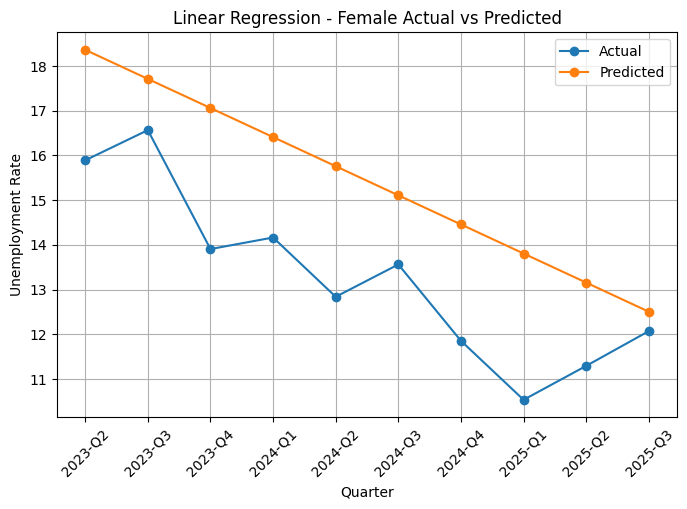

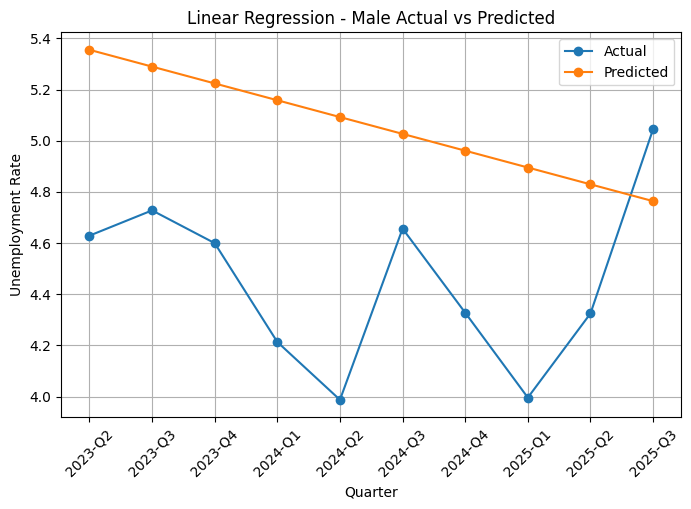

In [19]:
# Linear Regression Visualization

import matplotlib.pyplot as plt

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    X_gender = gdf[["t"]].values
    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    X_test = X_gender[split_idx:]
    y_test = y_gender[split_idx:]

    y_test_pred = linear_models[gender].predict(X_test)

    quarters = (
        gdf["Year"].astype(str)
        + "-Q"
        + gdf["Quarter_Number"].astype(str)
    ).iloc[split_idx:].values

    plt.figure(figsize=(8, 5))
    plt.plot(quarters, y_test, marker="o", label="Actual")
    plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

    plt.title(f"Linear Regression - {gender_name} Actual vs Predicted")
    plt.xlabel("Quarter")
    plt.ylabel("Unemployment Rate")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

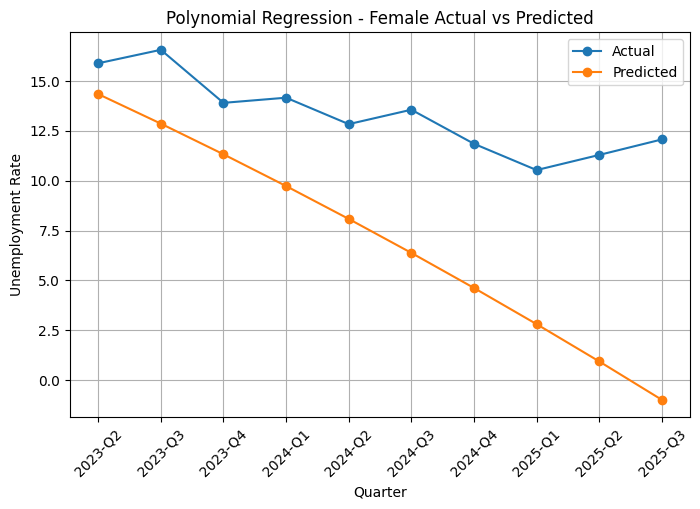

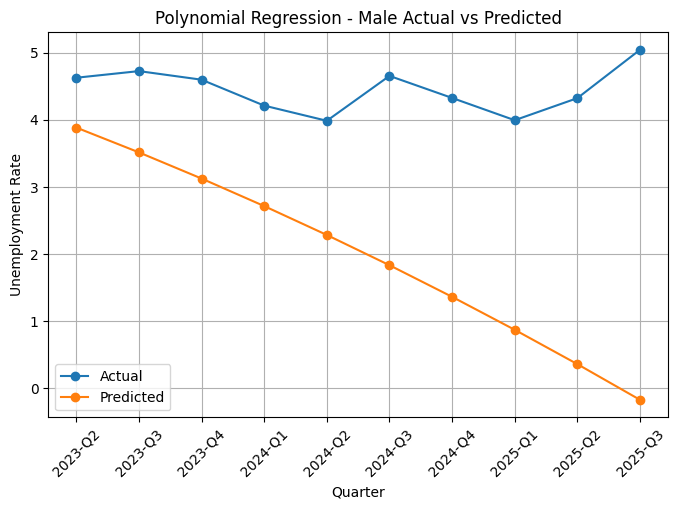

In [20]:
# Polynomial Regression Visualization

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    X_gender = gdf[["t"]].values
    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    X_test = X_gender[split_idx:]
    y_test = y_gender[split_idx:]

    y_test_pred = poly_models[gender].predict(X_test)

    quarters = (
        gdf["Year"].astype(str)
        + "-Q"
        + gdf["Quarter_Number"].astype(str)
    ).iloc[split_idx:].values

    plt.figure(figsize=(8, 5))
    plt.plot(quarters, y_test, marker="o", label="Actual")
    plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

    plt.title(f"Polynomial Regression - {gender_name} Actual vs Predicted")
    plt.xlabel("Quarter")
    plt.ylabel("Unemployment Rate")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

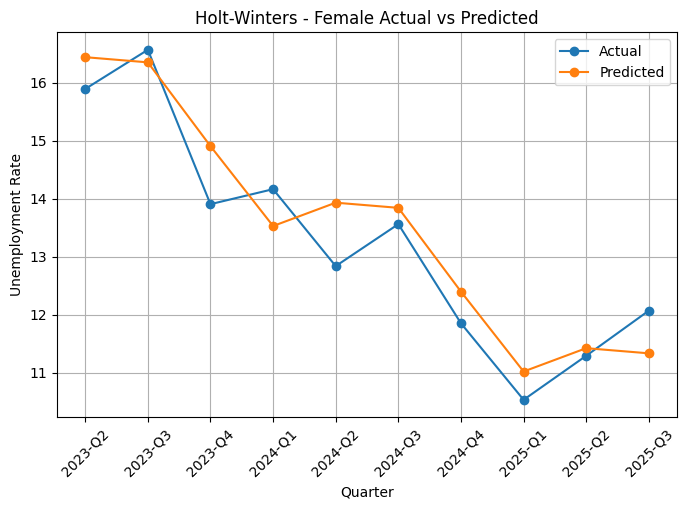

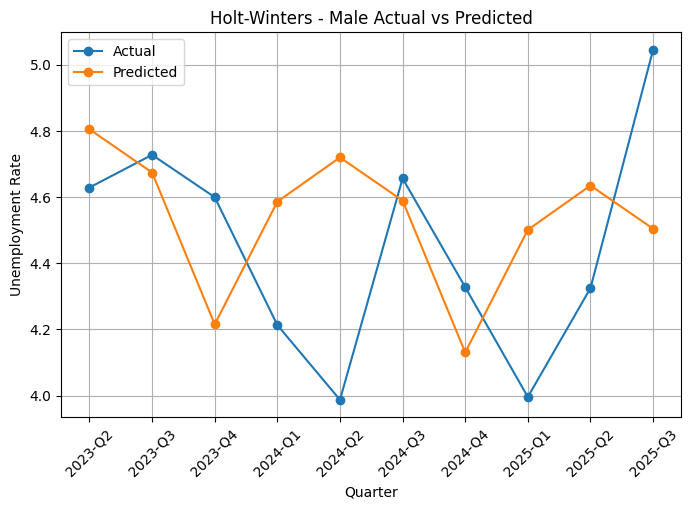

In [21]:
# Holt-Winters Visualization

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    y_test = y_gender[split_idx:]
    y_test_pred = holt_models[gender].forecast(len(y_test))

    quarters = (
        gdf["Year"].astype(str)
        + "-Q"
        + gdf["Quarter_Number"].astype(str)
    ).iloc[split_idx:].values

    plt.figure(figsize=(8, 5))
    plt.plot(quarters, y_test, marker="o", label="Actual")
    plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

    plt.title(f"Holt-Winters - {gender_name} Actual vs Predicted")
    plt.xlabel("Quarter")
    plt.ylabel("Unemployment Rate")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

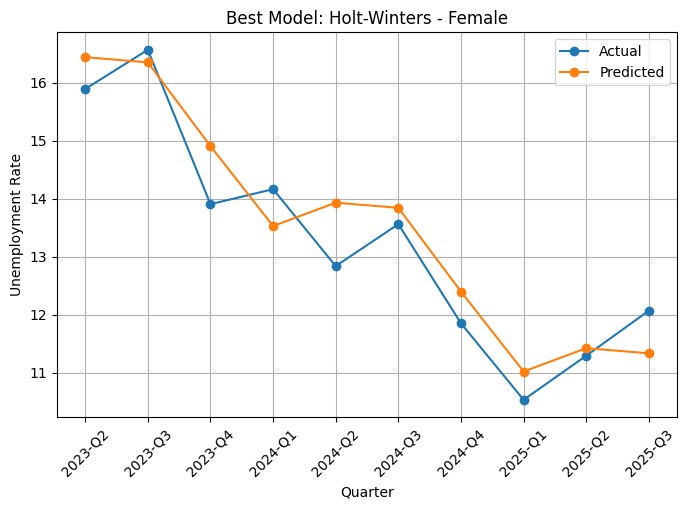

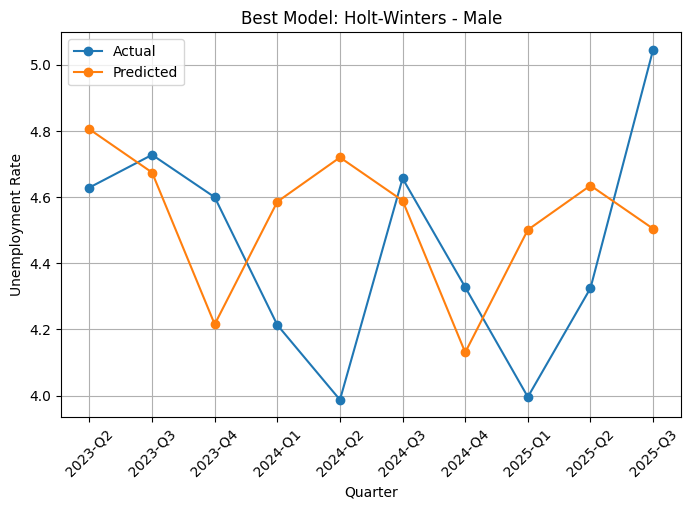

In [22]:
# Best Model Visualization: Holt-Winters

# The gender_names dictionary is redundant as `gender` is already a string

for gender in sorted(df["Gender"].unique()):

    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    y_gender = gdf["Unemployment_Rate"].values

    split_idx = len(y_gender) - test_size

    y_test = y_gender[split_idx:]
    y_test_pred = holt_models[gender].forecast(len(y_test))

    quarters = (
        gdf["Year"].astype(str)
        + "-Q"
        + gdf["Quarter_Number"].astype(str)
    ).iloc[split_idx:].values

    plt.figure(figsize=(8, 5))
    plt.plot(quarters, y_test, marker="o", label="Actual")
    plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

    plt.title(f"Best Model: Holt-Winters - {gender_name}")
    plt.xlabel("Quarter")
    plt.ylabel("Unemployment Rate")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

In [24]:
import os
import pandas as pd

# Test 1: Dataset loaded correctly
assert not df.empty, "Dataset is empty"

# Test 2: Target column exists
assert "Unemployment_Rate" in df.columns, "Target column missing"

# Test 3: No missing values after preprocessing
assert df.isnull().sum().sum() == 0, "Missing values found"

# Test 4: Integration test between preprocessing and training modules

# Verify that the cleaned dataset file was created
assert os.path.exists("cleaned_unemployment_data.csv"), "Cleaned dataset file not found"

# Load the cleaned dataset created in the preprocessing module
cleaned_df = pd.read_csv("cleaned_unemployment_data.csv")

# Verify that the cleaned dataset is not empty
assert not cleaned_df.empty, "Cleaned dataset is empty"

# Verify that the target column still exists
assert "Unemployment_Rate" in cleaned_df.columns, "Target column missing in cleaned dataset"

# Fix for Test 5: Model generated predictions
# The variables y_test_pred_lr and y_test are not globally defined from previous cells.
# We will use the 'Male' gender's linear regression predictions and test data for this example.
gender_to_check = list(linear_models.keys())[0]

# Get the X_test and y_test for the selected gender from the test_data dictionary
X_test = test_data[gender_to_check]['X_test']
y_test = test_data[gender_to_check]['y_test']

# Get the trained Linear Regression model for the selected gender
linear_model = linear_models[gender_to_check]

# Generate predictions using the Linear Regression model
y_test_pred_lr = linear_model.predict(X_test)

# Test 5: Model generated predictions
assert len(y_test_pred_lr) > 0, "No predictions generated"

# Verify prediction output size matches test labels
assert len(y_test_pred_lr) == len(y_test), "Prediction size does not match test set size"

print("All tests passed successfully.")

All tests passed successfully.


In [25]:
import time
import numpy as np
import pandas as pd # Import pandas for df.read_csv

# Load and prepare data (ensure df is available)
df = pd.read_csv("cleaned_unemployment_data.csv")

print("--- Holt-Winters Model Performance testing ---")
print("\n")

for gender in sorted(df["Gender"].unique()):
    gender_name = gender # Directly use gender as it's already a string

    gdf = (
        df[df["Gender"] == gender]
        .copy()
        .sort_values(["Year", "Quarter_Number"])
        .reset_index(drop=True)
    )

    y_gender = gdf["Unemployment_Rate"].values
    split_idx = len(y_gender) - test_size
    y_train = y_gender[:split_idx]
    y_test = y_gender[split_idx:]

    print(f"Testing for {gender_name}:")

    # Measure Training Time
    start_time = time.time()
    # Retrain the model to measure training time accurately
    hw_temp = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=4
    ).fit(optimized=True)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"  Training Time: {training_time:.4f} seconds")

    # Measure Single Prediction Time
    model_to_predict = holt_models[gender] # Use the already trained model
    start_time = time.time()
    _ = model_to_predict.forecast(len(y_test))
    end_time = time.time()
    single_prediction_time = end_time - start_time
    print(f"  Single Prediction Time: {single_prediction_time:.4f} seconds")

    # Measure 100 Predictions Time
    num_predictions_runs = 100
    start_time = time.time()
    for _ in range(num_predictions_runs):
        _ = model_to_predict.forecast(len(y_test))
    end_time = time.time()
    total_100_predictions_time = end_time - start_time
    avg_prediction_time = total_100_predictions_time / num_predictions_runs
    print(f"  Time for {num_predictions_runs} Predictions: {total_100_predictions_time:.4f} seconds")
    print(f"  Average Prediction Time (over {num_predictions_runs} runs): {avg_prediction_time:.6f} seconds")
    print("\n")

--- Holt-Winters Model Performance testing ---


Testing for Female:
  Training Time: 0.1286 seconds
  Single Prediction Time: 0.0020 seconds
  Time for 100 Predictions: 0.2320 seconds
  Average Prediction Time (over 100 runs): 0.002320 seconds


Testing for Male:
  Training Time: 0.1696 seconds
  Single Prediction Time: 0.0018 seconds
  Time for 100 Predictions: 0.2119 seconds
  Average Prediction Time (over 100 runs): 0.002119 seconds


